In [30]:
import numpy as np
import pandas as pd

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

In [32]:
df = pd.read_csv(r"C:\Users\Vivek\Downloads\Affairs.csv")

# Overview

In [33]:
df.head()

,rownames,affairs,gender,age,yearsmarried,children,religiousness,education,occupation,rating
0,4,0,male,37.0,10.00,no,3,18,7,4
1,5,0,female,27.0,4.00,no,4,14,6,4
2,11,0,female,32.0,15.00,yes,1,12,1,4
3,16,0,male,57.0,15.00,yes,5,18,6,5
4,23,0,male,22.0,0.75,no,2,17,6,3


In [34]:
df.describe(include="all")

,rownames,affairs,gender,age,yearsmarried,children,religiousness,education,occupation,rating
count,601.000000,601.000000,601,601.000000,601.000000,601,601.000000,601.000000,601.000000,601.000000
unique,NaN,NaN,2,NaN,NaN,2,NaN,NaN,NaN,NaN
top,NaN,NaN,female,NaN,NaN,yes,NaN,NaN,NaN,NaN
freq,NaN,NaN,315,NaN,NaN,430,NaN,NaN,NaN,NaN
mean,1059.722130,1.455907,NaN,32.487521,8.177696,NaN,3.116473,16.166389,4.194676,3.931780
std,914.904611,3.298758,NaN,9.288762,5.571303,NaN,1.167509,2.402555,1.819443,1.103179
min,4.000000,0.000000,NaN,17.500000,0.125000,NaN,1.000000,9.000000,1.000000,1.000000
25%,528.000000,0.000000,NaN,27.000000,4.000000,NaN,2.000000,14.000000,3.000000,3.000000
50%,1009.000000,0.000000,NaN,32.000000,7.000000,NaN,3.000000,16.000000,5.000000,4.000000
75%,1453.000000,0.000000,NaN,37.000000,15.000000,NaN,4.000000,18.000000,6.000000,5.000000


In [35]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 601 entries, 0 to 600
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   rownames       601 non-null    int64  
 1   affairs        601 non-null    int64  
 2   gender         601 non-null    str    
 3   age            601 non-null    float64
 4   yearsmarried   601 non-null    float64
 5   children       601 non-null    str    
 6   religiousness  601 non-null    int64  
 7   education      601 non-null    int64  
 8   occupation     601 non-null    int64  
 9   rating         601 non-null    int64  
dtypes: float64(2), int64(6), str(2)
memory usage: 47.1 KB


## Insights
##### age - normal distribution
##### religiousness, education, occupation, rating - one hot encoded
##### occupation and education - Holingshead classification (reverse numbering)

# Distruibution

In [36]:
df.columns

Index(['rownames', 'affairs', 'gender', 'age', 'yearsmarried', 'children',
       'religiousness', 'education', 'occupation', 'rating'],
      dtype='str')

In [37]:
quant = ['affairs','age','yearsmarried']
categ = ['gender','children','religiousness','education','occupation','rating']

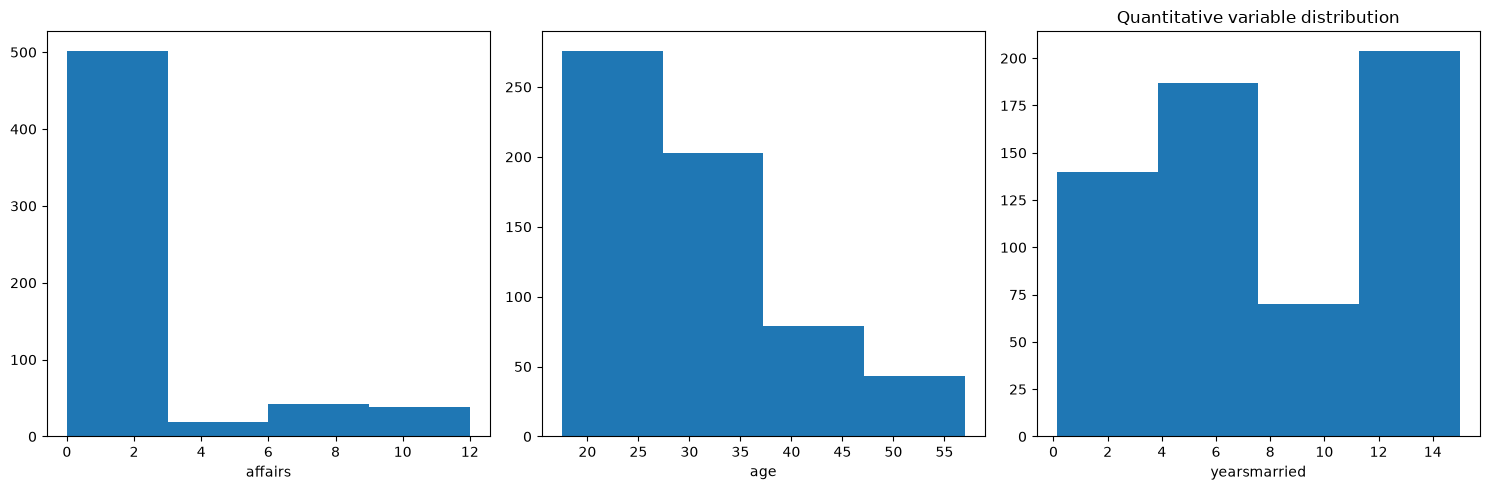

In [38]:
fig, ax = plt.subplots(1,3,figsize = (15,5))
for i in range(len(quant)):
    ax[i].hist(df[quant[i]],bins = 4)
    ax[i].set_xlabel(quant[i])
plt.title("Quantitative variable distribution")
plt.tight_layout()

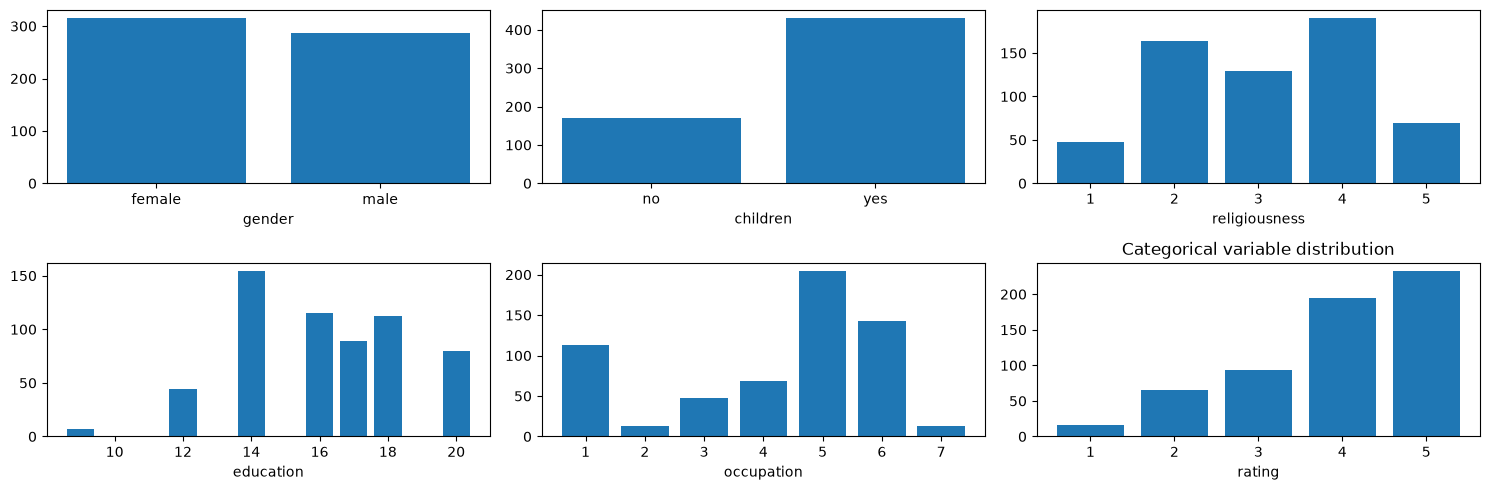

In [39]:
fig, ax = plt.subplots(2,3,figsize = (15,5))
cat = iter(categ)
def group(col):
    x = df.groupby(col)[col].count()
    return x
for i in range(2):
    for j in range(3):
        col = next(cat)
        y = group(col)
        ax[i][j].bar(y.index, y)
        ax[i][j].set_xlabel(col)
plt.title("Categorical variable distribution")
plt.tight_layout()

# Categorical variable wise sum of affairs

In [40]:
df.columns

Index(['rownames', 'affairs', 'gender', 'age', 'yearsmarried', 'children',
       'religiousness', 'education', 'occupation', 'rating'],
      dtype='str')

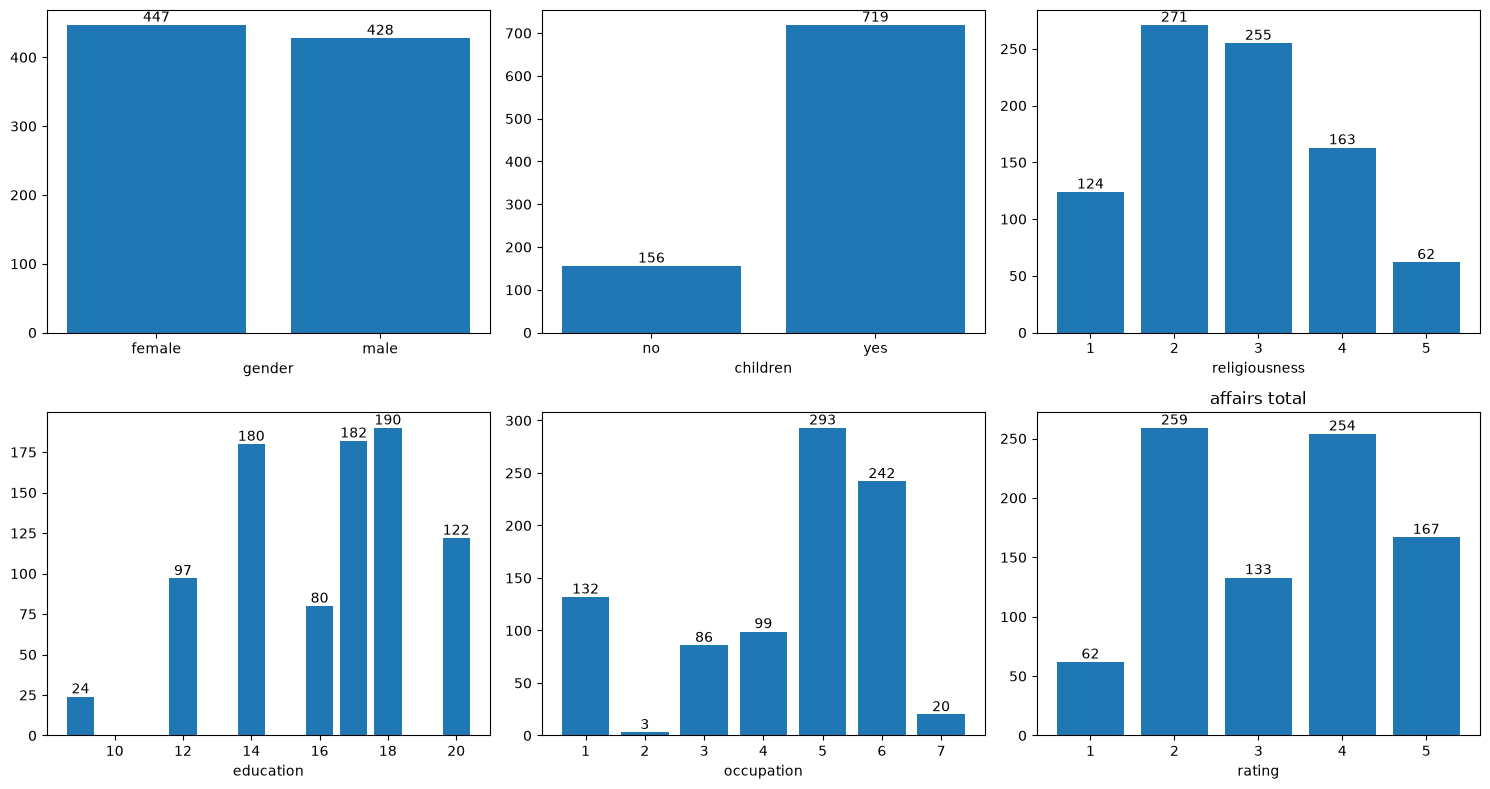

In [41]:
fig, ax = plt.subplots(2,3,figsize = (15,8))
cat = iter(categ)
def group(col):
    x = df.groupby(col)['affairs'].sum()
    return x
for i in range(2):
    for j in range(3):
        col = next(cat)
        y = group(col)
        bars = ax[i][j].bar(y.index, y)
        ax[i][j].bar_label(bars)
        ax[i][j].set_xlabel(col)
plt.title("affairs total")
plt.tight_layout()

## Insights
##### children - parents have more affairs
##### Religiousness - those who are not religious have more affairs
##### Education - educated people have more affairs
##### occupation - higher point scale means higher occupation
##### rating - both happier and unhappy people have affairs

# Education + Religiousness wise sum of affairs

In [42]:
df.columns

Index(['rownames', 'affairs', 'gender', 'age', 'yearsmarried', 'children',
       'religiousness', 'education', 'occupation', 'rating'],
      dtype='str')

In [43]:
edrelwise_affairs = df.groupby(['education','religiousness'])['affairs'].sum()

In [44]:
edrelwise_affairs

education  religiousness
9          3                12
           4                 0
           5                12
12         1                 8
           2                51
           3                13
           4                25
           5                 0
14         1                27
           2                32
           3                62
           4                55
           5                 4
16         1                10
           2                15
           3                 9
           4                36
           5                10
17         1                 4
           2                69
           3                85
           4                12
           5                12
18         1                61
           2                46
           3                57
           4                12
           5                14
20         1                14
           2                58
           3                17
           4  

In [45]:
edrelwise_affairs_unstack_T = edrelwise_affairs.unstack().T

In [46]:
edrelwise_affairs_unstack_T.fillna(0,inplace=True)

education,9,12,14,16,17,18,20
religiousness,,,,,,,
1,0.0,8.0,27.0,10.0,4.0,61.0,14.0
2,0.0,51.0,32.0,15.0,69.0,46.0,58.0
3,12.0,13.0,62.0,9.0,85.0,57.0,17.0
4,0.0,25.0,55.0,36.0,12.0,12.0,23.0
5,12.0,0.0,4.0,10.0,12.0,14.0,10.0


In [47]:
edrelwise_affairs_unstack_T.columns.array

<NumpyExtensionArray>
[9, 12, 14, 16, 17, 18, 20]
Length: 7, dtype: int64

In [48]:
np.zeros(7)

array([0., 0., 0., 0., 0., 0., 0.])

Text(0.5, 1.0, 'Education and Religiousnes wise total affairs')

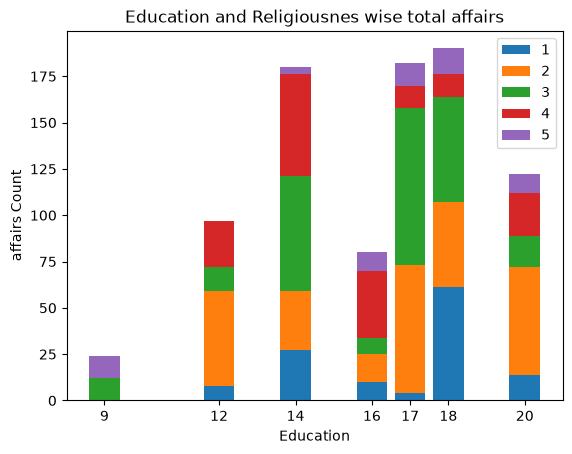

In [59]:
fig,ax = plt.subplots()
bottom = np.zeros(7)
for key in edrelwise_affairs_unstack_T.index:
    ax.bar(edrelwise_affairs_unstack_T.columns,height=edrelwise_affairs_unstack_T.loc[key,:].values,bottom=bottom,align='center',tick_label = edrelwise_affairs_unstack_T.columns)
    bottom = bottom + edrelwise_affairs_unstack_T.loc[key,:].values
    ax.set_xlabel("Education")
    ax.set_ylabel("affairs Count")
    ax.legend(edrelwise_affairs_unstack_T.index)
plt.title("Education and Religiousnes wise total affairs")


# Data set careation

In [50]:
import io

In [51]:
DimReligiousness = """bianry, actual
1, anti
2, not at all
3, slightly
4, somewhat
5, very"""

In [52]:
df_rel = pd.read_csv(io.StringIO(DimReligiousness))
df_rel

,bianry,actual
0,1,anti
1,2,not at all
2,3,slightly
3,4,somewhat
4,5,very


In [53]:
DimEducation = """binary, actual
9, grade school
12, high school graduate
14, some college
16, college graduate
17, some graduate work
18, master's degree
20, Ph.D/M.D"""


In [54]:
df_ed = pd.read_csv(io.StringIO(DimEducation))
df_ed

,binary,actual
0,9,grade school
1,12,high school graduate
2,14,some college
3,16,college graduate
4,17,some graduate work
5,18,master's degree
6,20,Ph.D/M.D


In [55]:
DimOccupation = """binary, actual
9, higher executive/proprietor of large businesses/major professional
8, administrators/lesser professionals/proprietor of medium-sized business
7, smaller business owners/ farm owners/ managers/ minor professionals
6, technicians/semi-professionals/small business owners(business valued at $50,000-70,000) 
5, clerical and sales workers/ small farm and business owners (business valued at $25,000-50,000) 
4, smaller business owners (<$25,000)/ skilled manual laborers/ craftsme/ tenant farmers 
3, machine operators and semi-skilled workers
2, unskilled workers
1, farm laborers/menial service workers/ students/ housewives"""

In [56]:
rows = [line.split(',', 1) for line in DimOccupation.strip().splitlines()]
df_occ = pd.DataFrame(rows[1:], columns=[col.strip() for col in rows[0]])
df_occ
df_occ

,binary,actual
0,9,higher executive/proprietor of large business...
1,8,administrators/lesser professionals/proprieto...
2,7,smaller business owners/ farm owners/ manager...
3,6,technicians/semi-professionals/small business...
4,5,clerical and sales workers/ small farm and bu...
5,4,"smaller business owners (<$25,000)/ skilled m..."
6,3,machine operators and semi-skilled workers
7,2,unskilled workers
8,1,farm laborers/menial service workers/ student...


In [57]:
DimRating = """bianry, actual
1, very unhappy
2, somewhat unhappy
3, average
4, happier than average
5, very happy"""

In [58]:
df_rat = pd.read_csv(io.StringIO(DimRating))
df_rat

,bianry,actual
0,1,very unhappy
1,2,somewhat unhappy
2,3,average
3,4,happier than average
4,5,very happy


Text(0.5, 1.0, 'Education and Religiousnes wise total affairs')

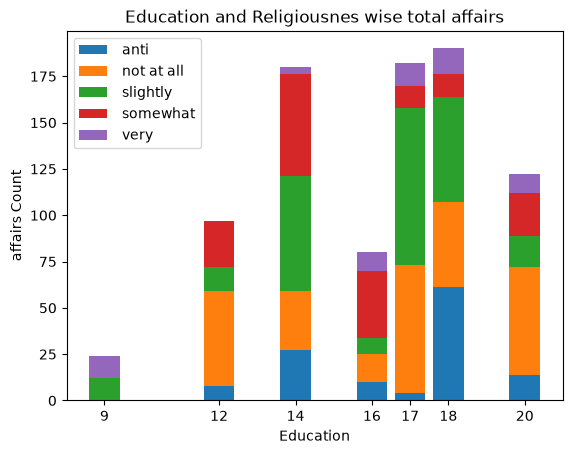

In [60]:
fig,ax = plt.subplots()
bottom = np.zeros(7)
for key in edrelwise_affairs_unstack_T.index:
    ax.bar(edrelwise_affairs_unstack_T.columns,height=edrelwise_affairs_unstack_T.loc[key,:].values,bottom=bottom,align='center',tick_label = edrelwise_affairs_unstack_T.columns)
    bottom = bottom + edrelwise_affairs_unstack_T.loc[key,:].values
    ax.set_xlabel("Education")
    ax.set_ylabel("affairs Count")
    ax.legend(df_rel[' actual'])
plt.title("Education and Religiousnes wise total affairs")
